# Dataset Distribution Analysis

This notebook analyzes the characteristics of all datasets used in the dynamic activation functions experiments.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_utils import DatasetConfig, DataManager

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
def analyze_dataset(dataset_name: str) -> dict:
    """
    Analyze a dataset and return its characteristics.
    
    Parameters:
    -----------
    dataset_name : str
        Name of the dataset to analyze
    
    Returns:
    --------
    dict : Dictionary containing dataset statistics
    """
    config = DatasetConfig(dataset_type=dataset_name, random_state=42)
    dm = DataManager(config)
    X_train, X_test, y_train, y_test = dm.generate_dataset()
    
    # Combine train and test for overall stats
    X = np.vstack([X_train, X_test])
    y = np.concatenate([y_train, y_test])
    
    # Class distribution
    unique, counts = np.unique(y, return_counts=True)
    class_dist = dict(zip(unique, counts))
    
    stats = {
        'dataset': dataset_name,
        'total_samples': len(y),
        'train_samples': len(y_train),
        'test_samples': len(y_test),
        'n_features': X.shape[1],
        'class_0_count': class_dist.get(0, 0),
        'class_1_count': class_dist.get(1, 0),
        'class_0_pct': round(class_dist.get(0, 0) / len(y) * 100, 2),
        'class_1_pct': round(class_dist.get(1, 0) / len(y) * 100, 2),
        'imbalance_ratio': round(max(counts) / min(counts), 2),
    }
    
    return stats, X, y

In [5]:
# List of all datasets
datasets = [
    'breast_cancer', 'titanic', 'heart_disease', 'banknote',
    'pima_diabetes', 'german_credit', 'adult_income', 'higgs_small'
]

# Analyze all datasets
all_stats = []
dataset_data = {}

for ds in datasets:
    print(f"Loading {ds}...")
    stats, X, y = analyze_dataset(ds)
    all_stats.append(stats)
    dataset_data[ds] = {'X': X, 'y': y}

print("\nAll datasets loaded successfully!")

Loading breast_cancer...
Loading titanic...
Loading heart_disease...
Loading banknote...
Loading pima_diabetes...
Loading german_credit...
Loading adult_income...
Loading higgs_small...

All datasets loaded successfully!


In [6]:
# Create summary dataframe
summary_df = pd.DataFrame(all_stats)
summary_df = summary_df.set_index('dataset')
summary_df

,total_samples,train_samples,test_samples,n_features,class_0_count,class_1_count,class_0_pct,class_1_pct,imbalance_ratio
dataset,,,,,,,,,
breast_cancer,569,455,114,30,212,357,37.26,62.74,1.68
titanic,1309,1047,262,8,809,500,61.80,38.20,1.62
heart_disease,270,216,54,13,150,120,55.56,44.44,1.25
banknote,1372,1097,275,4,762,610,55.54,44.46,1.25
pima_diabetes,768,614,154,8,500,268,65.10,34.90,1.87
german_credit,1000,800,200,48,300,700,30.00,70.00,2.33
adult_income,48842,39073,9769,97,37155,11687,76.07,23.93,3.18
higgs_small,10000,8000,2000,28,4705,5295,47.05,52.95,1.13


## Dataset Size Comparison

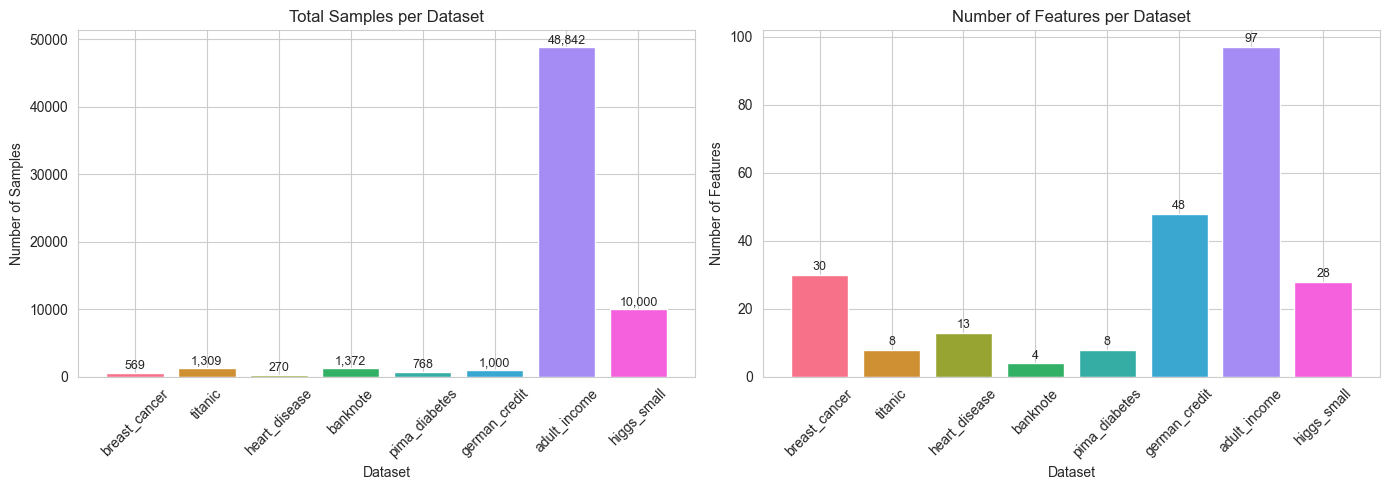

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of samples
ax1 = axes[0]
colors = sns.color_palette("husl", len(datasets))
bars = ax1.bar(summary_df.index, summary_df['total_samples'], color=colors)
ax1.set_xlabel('Dataset')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Dataset')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, summary_df['total_samples']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# Number of features
ax2 = axes[1]
bars = ax2.bar(summary_df.index, summary_df['n_features'], color=colors)
ax2.set_xlabel('Dataset')
ax2.set_ylabel('Number of Features')
ax2.set_title('Number of Features per Dataset')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, summary_df['n_features']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Class Distribution Analysis

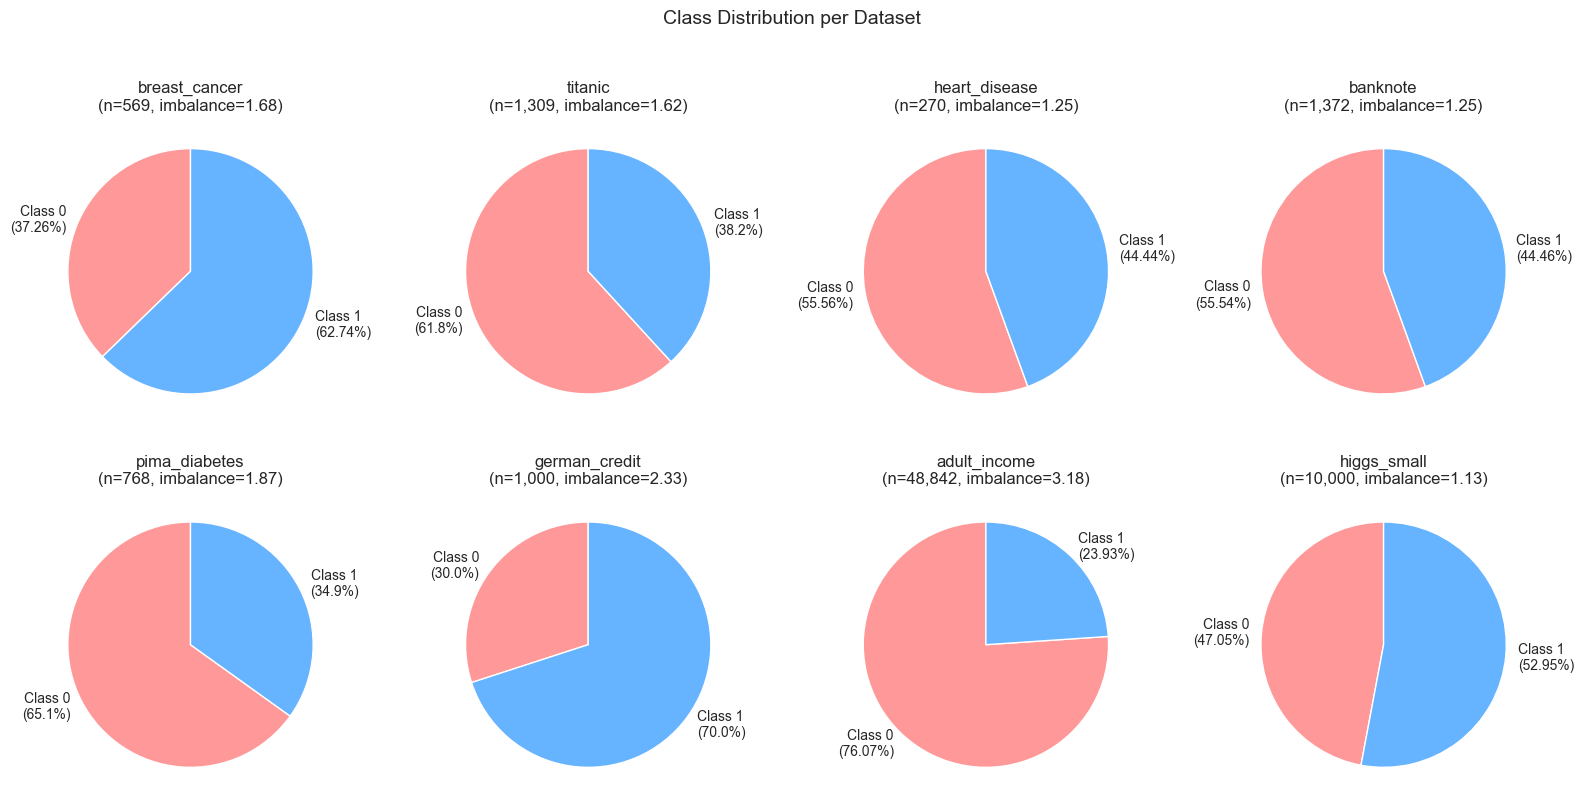

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, ds in enumerate(datasets):
    ax = axes[idx]
    stats = all_stats[idx]
    
    # Pie chart for class distribution
    sizes = [stats['class_0_count'], stats['class_1_count']]
    labels = [f'Class 0\n({stats["class_0_pct"]}%)', f'Class 1\n({stats["class_1_pct"]}%)']
    colors_pie = ['#ff9999', '#66b3ff']
    
    ax.pie(sizes, labels=labels, colors=colors_pie, autopct='', startangle=90)
    ax.set_title(f'{ds}\n(n={stats["total_samples"]:,}, imbalance={stats["imbalance_ratio"]})')

plt.suptitle('Class Distribution per Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Class Imbalance Comparison

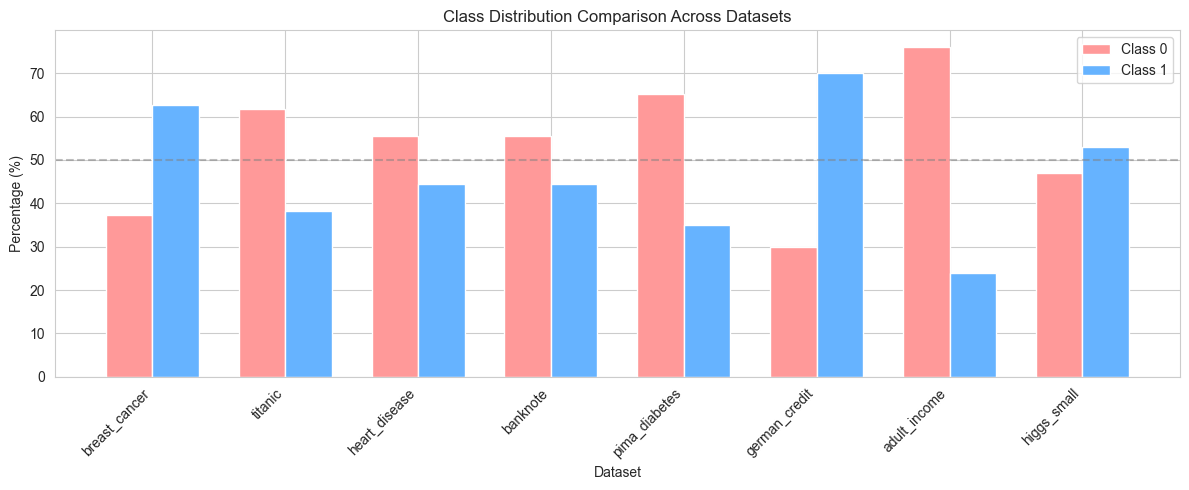

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, summary_df['class_0_pct'], width, label='Class 0', color='#ff9999')
bars2 = ax.bar(x + width/2, summary_df['class_1_pct'], width, label='Class 1', color='#66b3ff')

ax.set_xlabel('Dataset')
ax.set_ylabel('Percentage (%)')
ax.set_title('Class Distribution Comparison Across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.legend()
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Balanced')

plt.tight_layout()
plt.show()

## Dataset Complexity Overview

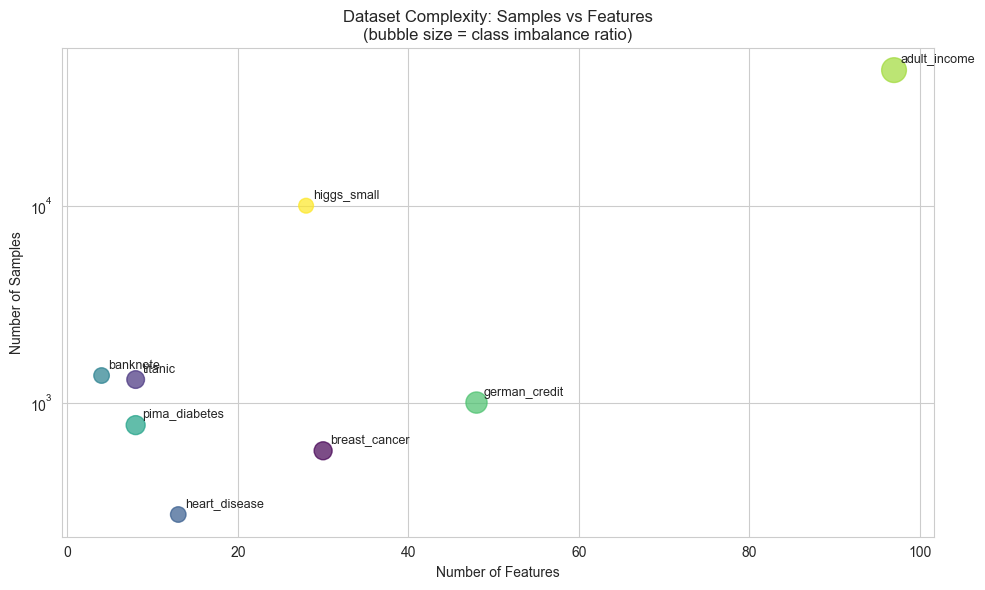

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot: samples vs features
scatter = ax.scatter(
    summary_df['n_features'], 
    summary_df['total_samples'],
    s=summary_df['imbalance_ratio'] * 100,  # Size by imbalance
    c=range(len(datasets)),
    cmap='viridis',
    alpha=0.7
)

# Add labels for each point
for i, ds in enumerate(datasets):
    ax.annotate(
        ds, 
        (summary_df.loc[ds, 'n_features'], summary_df.loc[ds, 'total_samples']),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=9
    )

ax.set_xlabel('Number of Features')
ax.set_ylabel('Number of Samples')
ax.set_title('Dataset Complexity: Samples vs Features\n(bubble size = class imbalance ratio)')
ax.set_yscale('log')  # Log scale for better visualization

plt.tight_layout()
plt.show()

## Summary Statistics Table

In [11]:
# Create a nicely formatted summary table
display_df = summary_df[['total_samples', 'n_features', 'class_0_pct', 'class_1_pct', 'imbalance_ratio']].copy()
display_df.columns = ['Total Samples', 'Features', 'Class 0 (%)', 'Class 1 (%)', 'Imbalance Ratio']

# Style the dataframe
styled_df = display_df.style.background_gradient(subset=['Total Samples'], cmap='Blues') \
    .background_gradient(subset=['Features'], cmap='Greens') \
    .background_gradient(subset=['Imbalance Ratio'], cmap='Reds') \
    .format({'Total Samples': '{:,}', 'Imbalance Ratio': '{:.2f}'})

styled_df

AttributeError: The '.style' accessor requires jinja2

In [12]:
# Save summary to CSV
summary_df.to_csv('dataset_summary.csv')
print("Summary saved to dataset_summary.csv")

Summary saved to dataset_summary.csv
